In [1]:
import h5py
import numpy as np
CRYSTAL = h5py.File('EELS_3D_div-out/EELS_3D_div_CRYSTAL-ex.h5')
EMPTY = h5py.File('EELS_3D_div-out/EELS_3D_div_EMPTY-ex.h5')

In [2]:
q_e = 1.60217646e-19

In [3]:
Esim_crystal    = CRYSTAL['ex']     # NOT normalized E field in MEEP units
FLUXsim_crystal = CRYSTAL['flux']   # Electric field flux in MEEP units
Esim_empty      = EMPTY['ex']       # NOT normalized E field in MEEP units
FLUXsim_empty   = EMPTY['flux']     # Electric field flux in MEEP units

In [4]:
crystal = Esim_crystal[()]
empty   = Esim_empty[()]

In [5]:
FLUXsim_crystal[0]

np.float64(0.0)

In [6]:
# Normalization factor alpha
alpha_crystal = -q_e/FLUXsim_crystal[1:]
alpha_empty   = -q_e/FLUXsim_empty[1:]

crystal = alpha_crystal*Esim_crystal[:,1:]    # Electric field for 1 electron in MEEP units
empty   = alpha_empty*Esim_empty[:,1:]        # Electric field for 1 electron in MEEP units

In [7]:
crystal

array([[ 1.48144012e-21,  2.66252764e-22, -3.88713606e-22, ...,
        -3.91804580e-22, -3.89501945e-22, -3.67544811e-22],
       [ 1.25003432e-20,  6.33823746e-21,  4.26930061e-21, ...,
        -6.15054765e-22, -6.17898787e-22, -5.89652151e-22],
       [-0.00000000e+00,  8.35097669e-22,  1.65336850e-21, ...,
         5.67446519e-22,  5.66238107e-22,  5.38953619e-22],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         9.45439953e-22,  1.04733511e-21,  9.54524797e-22],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -6.97520943e-22, -1.01143974e-22,  5.86013467e-22],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -6.77955187e-22, -9.29768552e-22, -1.10368651e-21]],
      shape=(866, 3150))

In [8]:
empty

array([[ 1.48144012e-21,  2.66252764e-22, -3.88713606e-22, ...,
        -9.06296971e-22, -9.07294992e-22, -8.58750212e-22],
       [ 1.25003432e-20,  6.33823746e-21,  4.26930061e-21, ...,
        -5.68995149e-22, -5.69894332e-22, -5.39675758e-22],
       [-0.00000000e+00,  8.35097669e-22,  1.65336850e-21, ...,
         6.19642746e-22,  6.20459904e-22,  5.87401819e-22],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         9.48124318e-22,  1.05628851e-21,  9.58751818e-22],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -7.47733179e-22, -1.37519495e-22,  5.60293498e-22],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -7.61074428e-22, -1.01122874e-21, -1.17476714e-21]],
      shape=(866, 3150))

In [9]:
diff = crystal - empty  # Eind in MEEP units
diff

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         5.14492391e-22,  5.17793047e-22,  4.91205402e-22],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -4.60596165e-23, -4.80044554e-23, -4.99763936e-23],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -5.21962264e-23, -5.42217972e-23, -4.84482000e-23],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -2.68436471e-24, -8.95340089e-24, -4.22702037e-24],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         5.02122361e-23,  3.63755209e-23,  2.57199686e-23],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         8.31192411e-23,  8.14601850e-23,  7.10806292e-23]],
      shape=(866, 3150))

In [10]:
with h5py.File("crystal_div.hdf5", "w") as f:
    dset = f.create_dataset("ex", empty.shape, dtype='<f8', data=crystal)

In [11]:
with h5py.File("empty_div.hdf5", "w") as f:
    dset = f.create_dataset("ex", crystal.shape, dtype='<f8', data=empty)

In [12]:
with h5py.File("diff_div.hdf5", "w") as f:
    dset = f.create_dataset("ex", diff.shape, dtype='<f8', data=diff)

# Check how the flux changes over time

In [13]:
import matplotlib.pyplot as plt

In [14]:
t = np.arange(0,len(FLUXsim_crystal))

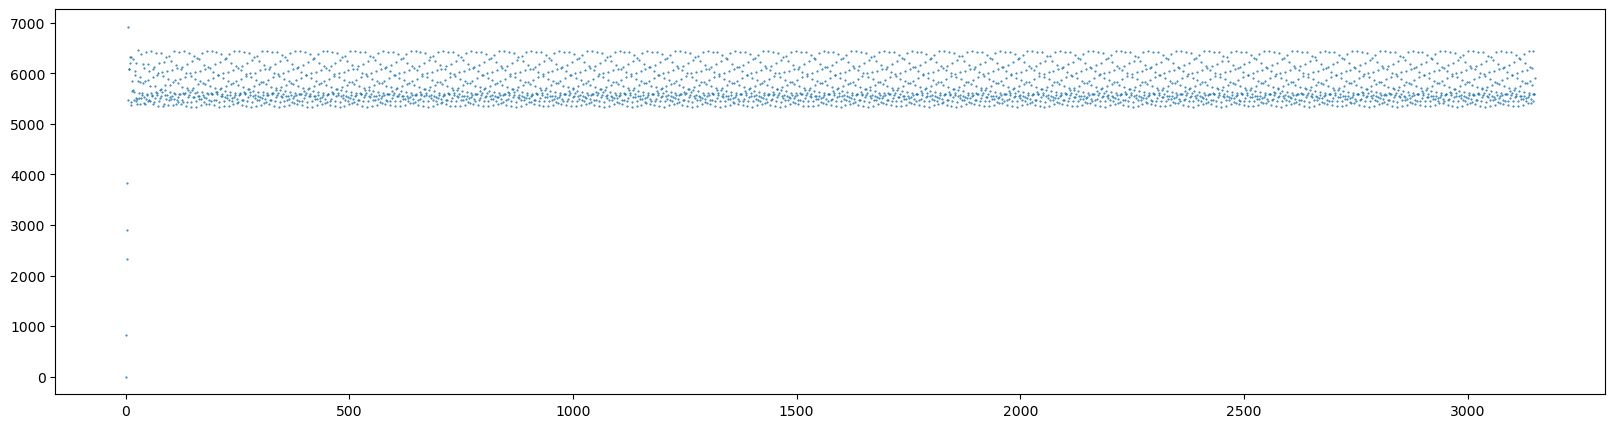

In [15]:
plt.figure(figsize=(20,5))
# plt.plot(t, FLUXsim_empty[()]/FLUXsim_empty[0]*100, '.', ms=1)
plt.plot(t[:], FLUXsim_crystal[:], '.', ms=1)

In [16]:
FLUXsim_crystal[()]

array([   0.        ,  825.34644171, 2327.26160185, ..., 5598.38084885,
       5592.75274853, 5903.52750401], shape=(3151,))